In [1]:
import os
import tensorflow as tf
from params import PARAMS
from PreDamagePreTech import PreDamagePreTechModel
from DeterministicSimulation  import load_PreDamagePreTech_model, simulate_path_PreDamagePreTech
 
# Example usage
import numpy as np 
import pathlib
import time
from feedforward_subnet import FeedForwardSubNet, setup_optimizers
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
export_folder                    = "/project/lhansen/Cap_damage/TwoStageTechJump/output/TechSearch_LR_piecewiseconstant_10e-4,10e-4,10e-4,10e-4_128_neurons_32_#HiddenLayer_4_num_iterations2000000"
export_folder                    = '/project/lhansen/Cap_damage/TwoStageTechJump/output/TechSearch_LR_piecewiseconstant_10e-6,10e-6,10e-6,10e-6_128_neurons_32_#HiddenLayer_4_num_iterations2000000'
export_folder                    = '/project/lhansen/Cap_damage/TwoStageTechJump/output/TechSearch_LR_piecewiseconstant_10e-5,10e-5,10e-5,10e-5_128_neurons_32_#HiddenLayer_4_num_iterations2000000'
# export_folder                    = '/project/lhansen/Cap_damage/TwoStageTechJump/output/TechSearch_LR_piecewiseconstant_20e-7,20e-7,20e-7,20e-7_128_neurons_32_#HiddenLayer_4_num_iterations2000000'
export_folder                    = '/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_warmup_cosine_10e-6,10e-6,10e-6,10e-6_128_neurons_32_#HiddenLayer_4_num_iterations1000000'
# export_folder                    = '/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_piecewiseconstant_10e-6,10e-6,10e-6,10e-6_128_neurons_32_#HiddenLayer_4_num_iterations1000000'
export_folder                    =  "/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_piecewiseconstant_10e-5,10e-5,10e-5,10e-5_128_neurons_32_#HiddenLayer_4_num_iterations1000000"
export_folder                    = '/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_warmup_cosine_40e-6,40e-6,40e-6,40e-6_128_neurons_32_#HiddenLayer_4_num_iterations1000000'
export_folder                    = "/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_piecewiseconstant_10e-4,10e-4,10e-4,10e-4_128_neurons_32_#HiddenLayer_4_num_iterations1000000"
export_folder                    ="/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_warmup_cosine_40e-5,40e-5,40e-5,40e-5_128_neurons_32_#HiddenLayer_4_num_iterations1000000"
export_folder   ="/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_piecewiseconstant_40e-6,40e-6,40e-6,40e-6_128_neurons_32_#HiddenLayer_4_num_iterations1000000"
export_folder   ="/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_piecewiseconstant_40e-5,40e-5,40e-5,40e-5_128_neurons_32_#HiddenLayer_4_num_iterations1000000"
export_folder                    = '/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_warmup_cosine_10e-6,10e-6,10e-6,10e-6_128_neurons_32_#HiddenLayer_4_num_iterations1000000' 

batch_size                       = int("128")
num_iterations                   = int("2000000")
pretrained_path = None
logging_frequency                = 1000
learning_rates                   = [float(x) for x in "10e-4,10e-4,10e-4,10e-4".split(",")]
hidden_layer_activations         = "swish,tanh,tanh,softplus".split(",")
output_layer_activations         = "softplus,custom,custom,softplus".split(",")
num_hidden_layers                = int("4")
num_neurons                      = int("32")
learning_rate_schedule_type      = "piecewiseconstant"
export_folder_output             = "DeterministicSimulation"
    
    
hidden_layer_activations   = [None if x == "None" else x for x in hidden_layer_activations]
output_layer_activations   = [None if x == "None" else x for x in output_layer_activations]


v_nn_config   = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[0], "dim" : 1, "nn_name" : "v_nn"}
v_nn_config["final_activation"] = output_layer_activations[0]

i_g_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[1], "dim" : 1, "nn_name" : "i_g_nn"}
i_g_nn_config["final_activation"] = output_layer_activations[1]

i_d_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[2], "dim" : 1, "nn_name" : "i_d_nn"}
i_d_nn_config["final_activation"] = output_layer_activations[2]


i_r_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[3], "dim" : 1, "nn_name" : "i_r_nn"}
i_r_nn_config["final_activation"] = output_layer_activations[3]

params = {"batch_size" : batch_size, "learning_rates":learning_rates,
"v_nn_config" : v_nn_config, "i_g_nn_config" : i_g_nn_config, "i_d_nn_config" : i_d_nn_config, "i_r_nn_config" : i_r_nn_config,
"num_iterations" : num_iterations, "logging_frequency": logging_frequency, "verbose": True, 
"pretrained_path" : pretrained_path, "learning_rate_schedule_type" : learning_rate_schedule_type}

params["export_folder"]  = export_folder +  "/PreDamagePreTech"
params["job_name"] =export_folder
params["v_PostDamagePostTech_nn_path"]  = export_folder +  "/PostDamagePostTech/v_nn_checkpoint_PostDamagePostTech"
params["v_PreDamagePostTech_nn_path"]  = export_folder +  "/PreDamagePostTech/v_nn_checkpoint_PreDamagePostTech"
params["v_PostDamagePreTech_nn_path"]  = export_folder +  "/PostDamagePreTech/v_nn_checkpoint_PostDamagePreTech"
params["v_PostDamageIntermTech_nn_path"]  = export_folder +  "/PostDamageIntermTech/v_nn_checkpoint_PostDamageIntermTech"
params["v_PreDamageIntermTech_nn_path"]  = export_folder +  "/PreDamageIntermTech/v_nn_checkpoint_PreDamageIntermTech"
## i_g and i_d activations come after params because we amy want to use phi_g and phi_d
phi_g = 16.7
phi_d = 16.7
if output_layer_activations[1] == "custom" or output_layer_activations[2] == "custom":
    params["i_g_nn_config"]["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ phi_g) / (tf.exp(2 * x) + 1.0)
    params["i_d_nn_config"]["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ phi_d) / (tf.exp(2 * x) + 1.0)

PARAMS.update(params)

model = load_PreDamagePreTech_model(export_folder)
print("Loaded PreDamagePreTech model with value, controls, and helper nets.")



Loaded PreDamagePreTech model with value, controls, and helper nets.
Loaded PreDamagePreTech model with value, controls, and helper nets.


In [22]:
# simulate_path_PreDamagePreTech(
#     model,
#     ξ= 5.0 ,
#     T=60.0,
#     dt=1/12,  )
# simulate_path_PreDamagePreTech(
#     model,
#     ξ= 0.3,
#     T=60.0,
#     dt=1/12,  )

# simulate_path_PreDamagePreTech(
#     model,
#     ξ= 0.1,
#     T=60.0,
#     dt=1/12,  )

# simulate_path_PreDamagePreTech(
#     model,
#     ξ= 0.075,
#     T=60.0,
#     dt=1/12,  )
simulate_path_PreDamagePreTech(
    model,
    ξ= 0.05,
    T=60.0,
    dt=1/12,  )

simulate_path_PreDamagePreTech(
    model,
    ξ= 0.035,
    T=60.0,
    dt=1/12,  )


Climate (damage) models distorted weights over λ3: [0.0281072  0.0671687  0.14767009 0.28660604 0.47044802]
Climate sensitivity distortion shift (varsigma * h_y_T): 2.0767137207090856e-05
Climate (damage) models distorted weights over λ3: [0.0281072  0.0671687  0.14767009 0.28660604 0.47044802]
Climate sensitivity distortion shift (varsigma * h_y_T): 2.0767137207090856e-05
[9.99996709e-01 3.29053742e-06]
[9.99996709e-01 3.29053742e-06]
Climate (damage) models distorted weights over λ3: [0.01041813 0.03591805 0.10977753 0.28046882 0.5634175 ]
Climate sensitivity distortion shift (varsigma * h_y_T): 2.940937189757824e-05
Climate (damage) models distorted weights over λ3: [0.01041813 0.03591805 0.10977753 0.28046882 0.5634175 ]
Climate sensitivity distortion shift (varsigma * h_y_T): 2.940937189757824e-05
[9.99999960e-01 3.99571143e-08]
[9.99999960e-01 3.99571143e-08]


{'t': array([ 0.        ,  0.08344924,  0.16689847,  0.25034771,  0.33379694,
         0.41724618,  0.50069541,  0.58414465,  0.66759388,  0.75104312,
         0.83449235,  0.91794159,  1.00139082,  1.08484006,  1.16828929,
         1.25173853,  1.33518776,  1.418637  ,  1.50208623,  1.58553547,
         1.6689847 ,  1.75243394,  1.83588317,  1.91933241,  2.00278164,
         2.08623088,  2.16968011,  2.25312935,  2.33657858,  2.42002782,
         2.50347705,  2.58692629,  2.67037552,  2.75382476,  2.83727399,
         2.92072323,  3.00417246,  3.0876217 ,  3.17107093,  3.25452017,
         3.3379694 ,  3.42141864,  3.50486787,  3.58831711,  3.67176634,
         3.75521558,  3.83866481,  3.92211405,  4.00556328,  4.08901252,
         4.17246175,  4.25591099,  4.33936022,  4.42280946,  4.50625869,
         4.58970793,  4.67315716,  4.7566064 ,  4.84005563,  4.92350487,
         5.0069541 ,  5.09040334,  5.17385257,  5.25730181,  5.34075104,
         5.42420028,  5.50764951,  5.59109875,

{'t': array([ 0.        ,  0.08344924,  0.16689847,  0.25034771,  0.33379694,
         0.41724618,  0.50069541,  0.58414465,  0.66759388,  0.75104312,
         0.83449235,  0.91794159,  1.00139082,  1.08484006,  1.16828929,
         1.25173853,  1.33518776,  1.418637  ,  1.50208623,  1.58553547,
         1.6689847 ,  1.75243394,  1.83588317,  1.91933241,  2.00278164,
         2.08623088,  2.16968011,  2.25312935,  2.33657858,  2.42002782,
         2.50347705,  2.58692629,  2.67037552,  2.75382476,  2.83727399,
         2.92072323,  3.00417246,  3.0876217 ,  3.17107093,  3.25452017,
         3.3379694 ,  3.42141864,  3.50486787,  3.58831711,  3.67176634,
         3.75521558,  3.83866481,  3.92211405,  4.00556328,  4.08901252,
         4.17246175,  4.25591099,  4.33936022,  4.42280946,  4.50625869,
         4.58970793,  4.67315716,  4.7566064 ,  4.84005563,  4.92350487,
         5.0069541 ,  5.09040334,  5.17385257,  5.25730181,  5.34075104,
         5.42420028,  5.50764951,  5.59109875,

In [2]:
 
export_folder                    = '/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_warmup_cosine_10e-6,10e-6,10e-6,10e-6_128_neurons_32_#HiddenLayer_4_num_iterations1000000'
# export_folder                    = '/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_piecewiseconstant_10e-6,10e-6,10e-6,10e-6_128_neurons_32_#HiddenLayer_4_num_iterations1000000'
# export_folder                    =  "/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_piecewiseconstant_10e-5,10e-5,10e-5,10e-5_128_neurons_32_#HiddenLayer_4_num_iterations1000000"
# # # export_folder                    ="/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_warmup_cosine_40e-5,40e-5,40e-5,40e-5_128_neurons_32_#HiddenLayer_4_num_iterations1000000"
# export_folder   ="/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_piecewiseconstant_40e-5,40e-5,40e-5,40e-5_128_neurons_32_#HiddenLayer_4_num_iterations1000000"


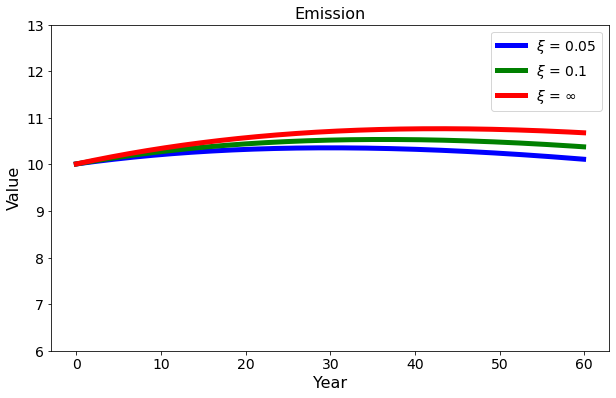

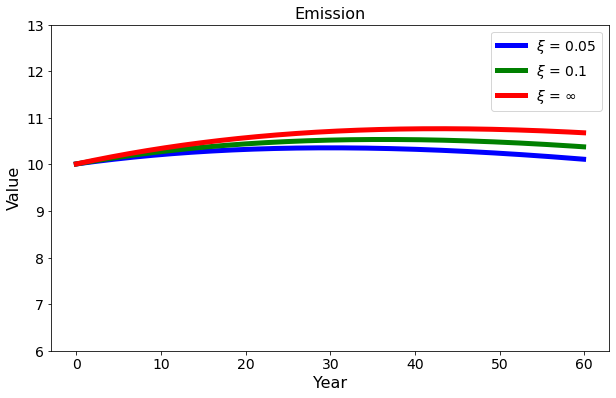

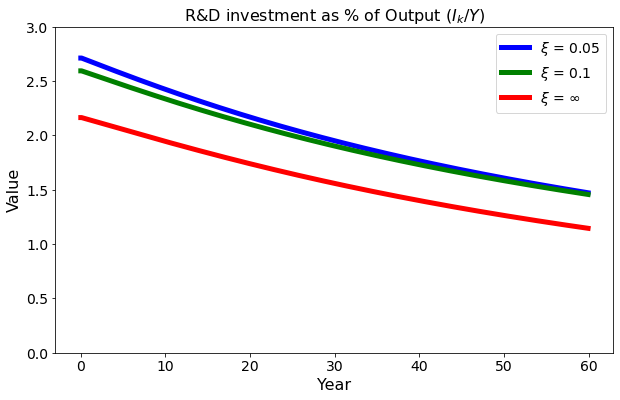

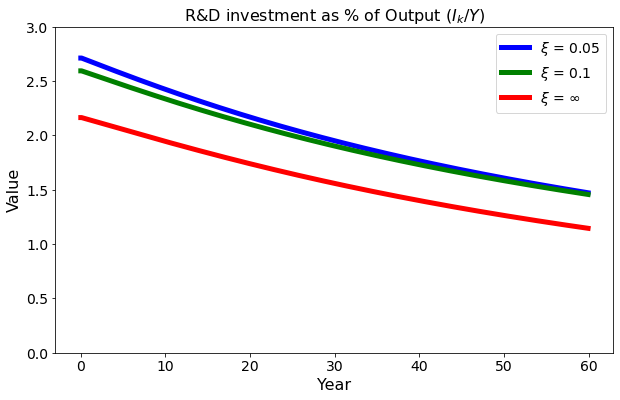

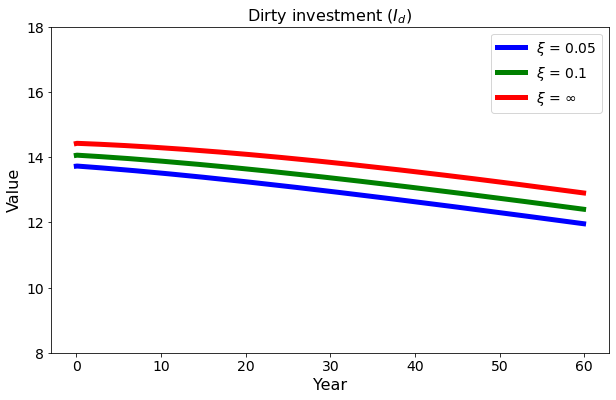

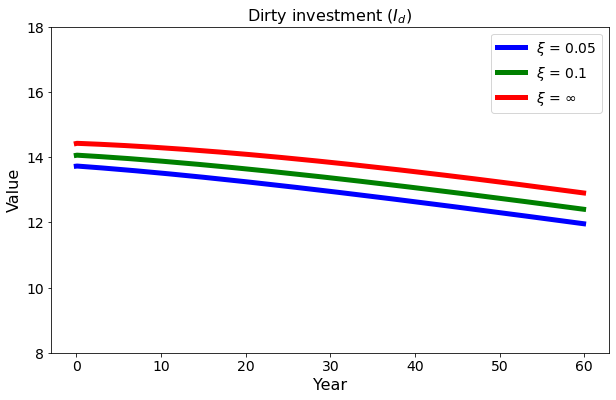

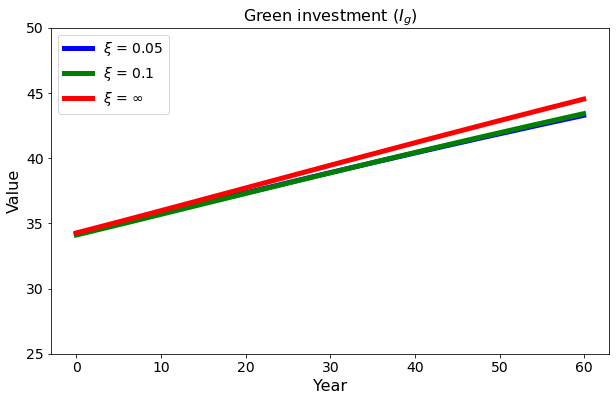

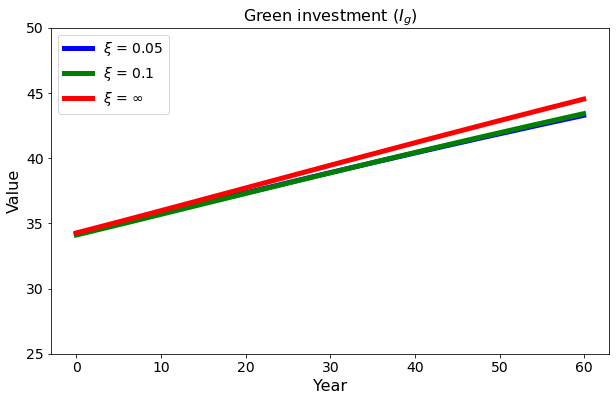

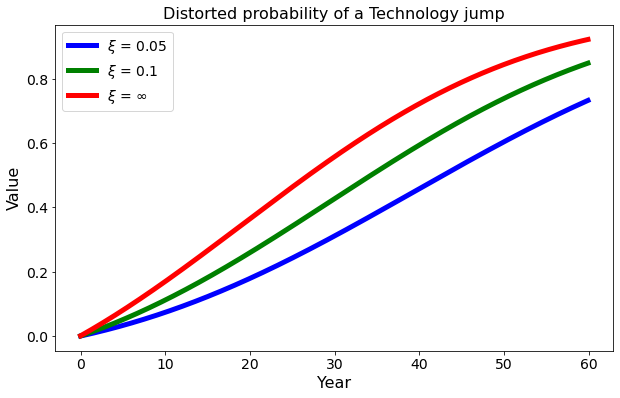

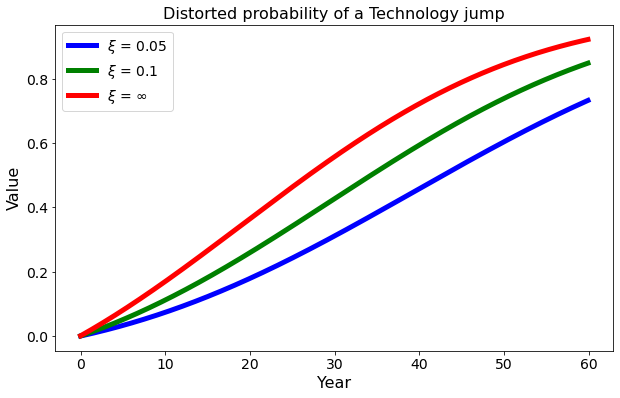

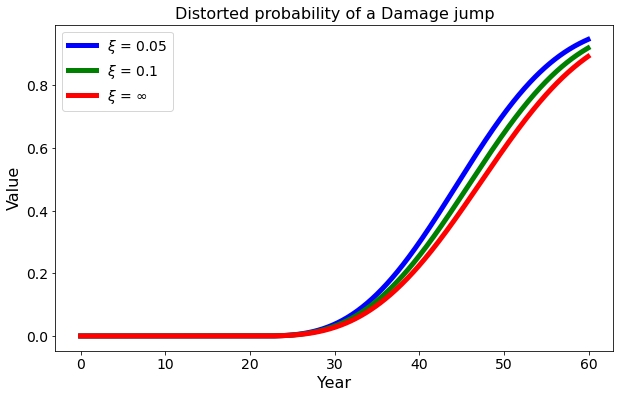

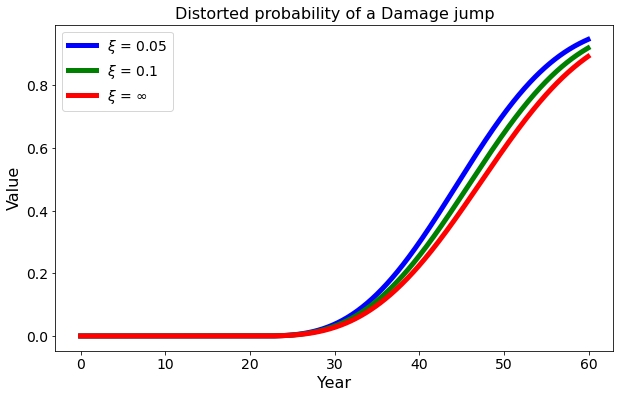

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# FolderName='/project/lhansen/Cap_damage/TwoStageTechJump/output/TechSearch_LR_piecewiseconstant_10e-6,10e-6,10e-6,10e-6_128_neurons_32_#HiddenLayer_4_num_iterations2000000'
FolderName=export_folder
# Function to read values from a file
def read_values(file_path):
    values = []
    with open(file_path, 'r') as file:
        for line in file:
            values.append(float(line.strip()))
    return values

Name=["E","RD","I_d","I_g","tech_jump_prob","dmg_jump_prob" ]
for txt_name in Name:
    # File paths 5, -1. -3
    # Cap_damage/TwoCapital_NN/output/A_g_prime_1_Delta_0.01_LR_piecewiseconstant_10e-5,10e-5,10e-5,10e-5_128_neurons_32_#HiddenLayer_4_logxi_-3.0_logximax_5.0_num_iterations600000
    file_path1 = FolderName+f'/PreDamagePreTech/SimulationOutputs_ξ_0.050/{txt_name}.txt'
    file_path2 = FolderName+f'/PreDamagePreTech/SimulationOutputs_ξ_0.100/{txt_name}.txt'
    file_path3 = FolderName+f'/PreDamagePreTech/SimulationOutputs_ξ_5.000/{txt_name}.txt'
#     file_path4 = FolderName+f'/PreDamagePreTech/{txt_name}.txt'
  
    # Read values from the files
    values1 = read_values(file_path1)
    values2 = read_values(file_path2)
    values3 = read_values(file_path3)
#     values4 = read_values(file_path4)
    values1 = values1[:720]  
    values2 = values2[:720]
    values3 = values3[:720]
#     values4 = values4[:720]
    # Indices for the values
    indices1 = [x / 12 for x in range(len(values1))]
    indices2 = [x / 12 for x in range(len(values2))]
    indices3 = [x / 12 for x in range(len(values3))]
#     indices4 = [x / 12 for x in range(len(values4))]

    # Plotting the values from both files
    plt.figure(figsize=(10, 6))

    if txt_name == "RD":
        values1 = [v * 100 for v in values1]
        values2 = [v * 100 for v in values2]
        values3 = [v * 100 for v in values3]
    
    plt.plot(indices1, values1,  color='b', label=r'$\xi$ = 0.05',linewidth=5)
    plt.plot(indices2, values2,  color='g', label=r'$\xi$ = 0.1',linewidth=5)
    plt.plot(indices3, values3,  color='r', label=r'$\xi$ = $\infty$',linewidth=5)
#     plt.plot(indices4, values4,  color='purple', label=r'$\xi$ = 0.075',linewidth=5)
    
    if txt_name == "RD":
        plt.title(r'R&D investment as % of Output $(I_k/Y)$',fontsize=16)
        plt.ylim(0, 3) 
    elif txt_name =="I_d":
        plt.title(r'Dirty investment $(I_d)$',fontsize=16)
        plt.ylim(8, 18) 
    elif txt_name =="I_g":
        plt.title(r'Green investment $(I_g)$',fontsize=16)
        plt.ylim(25, 50) 
    elif txt_name =="tech_jump_prob":
        plt.title('Distorted probability of a Technology jump',fontsize=16)
    elif txt_name =="dmg_jump_prob":
        plt.title('Distorted probability of a Damage jump',fontsize=16)
    elif txt_name =="TechJumpIntensity":
        plt.title('Distorted Intensity of a Technology jump',fontsize=16)
    elif txt_name =="DmgJumpIntensity":
        plt.title('Distorted Intensity of a Damage jump',fontsize=16)    
    elif txt_name =="E":
        plt.title('Emission',fontsize=16)  
        plt.ylim(6, 13 ) 
    else:
        plt.title(f'{txt_name}',fontsize=16)
    plt.xlabel('Year',fontsize=16)
    plt.ylabel('Value',fontsize=16)
    plt.xticks(fontsize=14)  
    plt.yticks(fontsize=14)  
    plt.legend(fontsize=14)  
    plt.show()

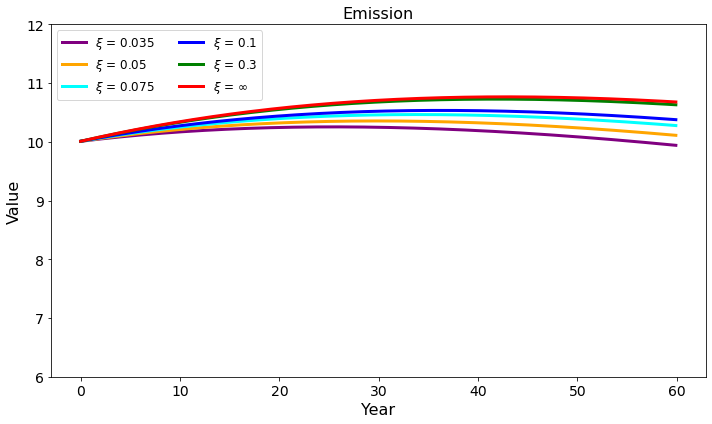

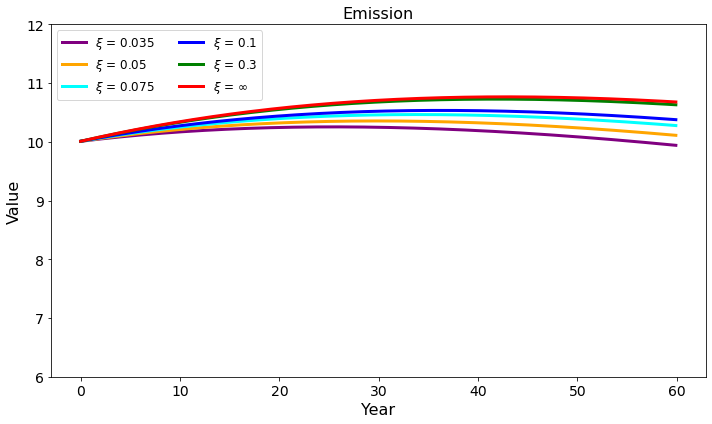

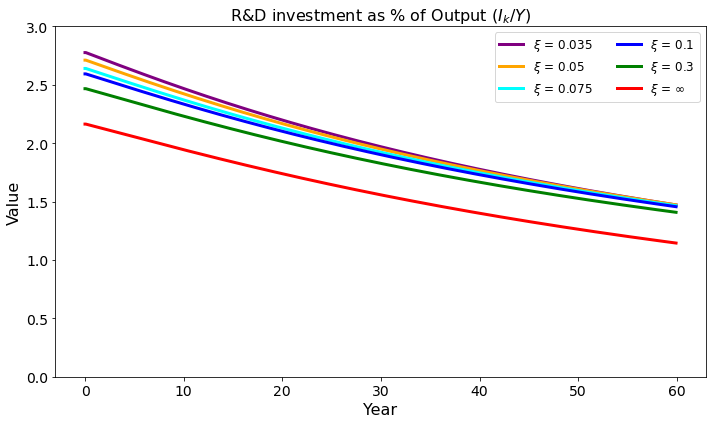

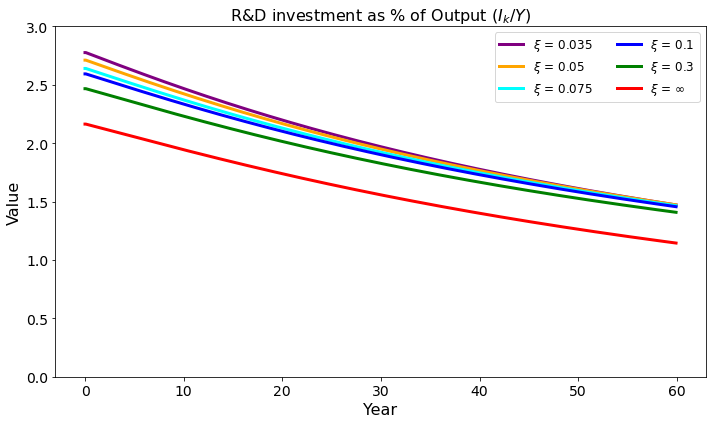

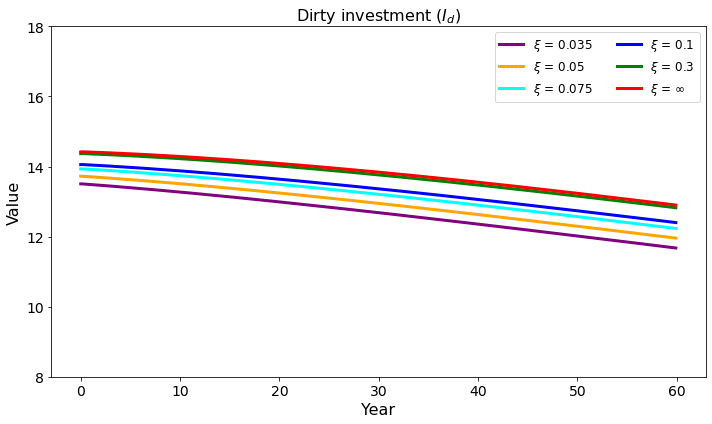

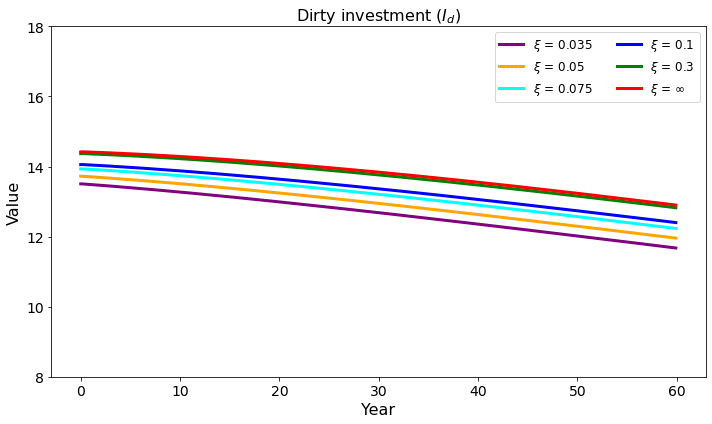

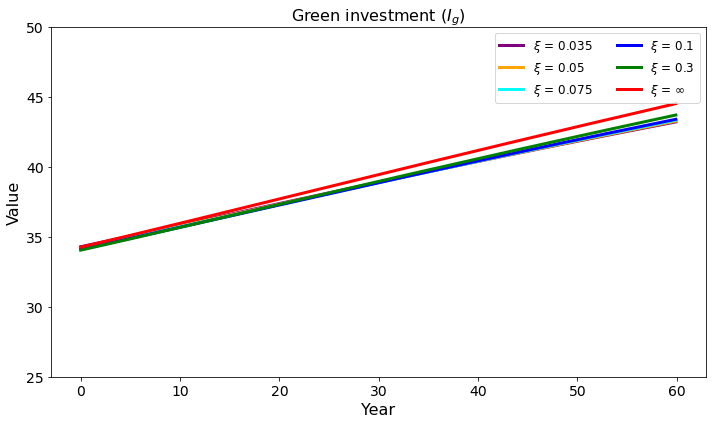

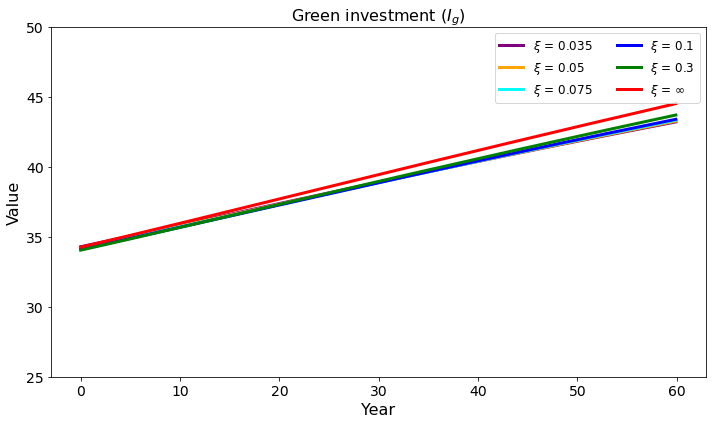

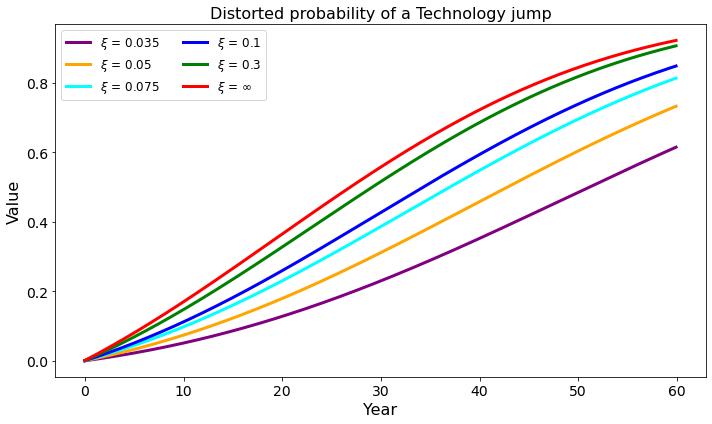

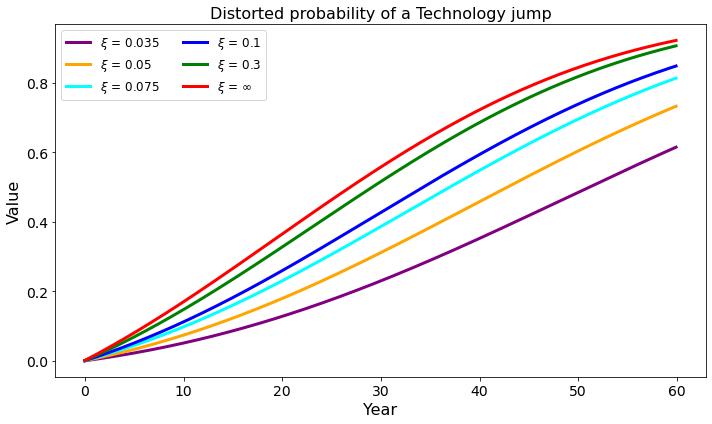

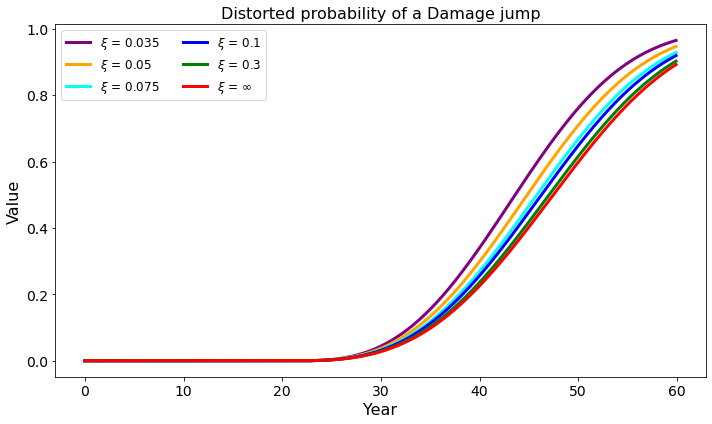

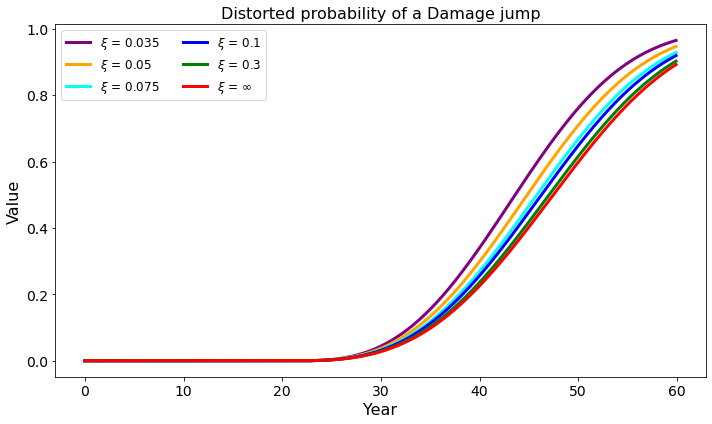

In [4]:
import matplotlib.pyplot as plt

# FolderName=export_folder
FolderName = export_folder  

# Function to read values from a file
def read_values(file_path):
    values = []
    with open(file_path, 'r') as file:
        for line in file:
            values.append(float(line.strip()))
    return values

Name = ["E", "RD", "I_d", "I_g", "tech_jump_prob", "dmg_jump_prob"]

for txt_name in Name:
    # Define file paths for all ξ values
    file_paths = {
        0.035: FolderName + f'/PreDamagePreTech/SimulationOutputs_ξ_0.035/{txt_name}.txt',
        0.050: FolderName + f'/PreDamagePreTech/SimulationOutputs_ξ_0.050/{txt_name}.txt',
        0.075: FolderName + f'/PreDamagePreTech/SimulationOutputs_ξ_0.075/{txt_name}.txt',
        0.100: FolderName + f'/PreDamagePreTech/SimulationOutputs_ξ_0.100/{txt_name}.txt',
        0.300: FolderName + f'/PreDamagePreTech/SimulationOutputs_ξ_0.300/{txt_name}.txt',
        float("inf"): FolderName + f'/PreDamagePreTech/SimulationOutputs_ξ_5.000/{txt_name}.txt'
    }

    # Colors for each ξ
    colors = {
        0.035: 'purple',
        0.050: 'orange',
        0.075: 'cyan',
        0.100: 'blue',
        0.300: 'green',
        float("inf"): 'red'
    }

    # Load and truncate values
    values_dict = {}
    for xi, path in file_paths.items():
        vals = read_values(path)[:720]
        if txt_name == "RD":
            vals = [v * 100 for v in vals]  # scale %
        values_dict[xi] = vals

    # Indices (years)
    indices = [x / 12 for x in range(720)]

    # Plotting
    plt.figure(figsize=(10, 6))
    for xi, vals in values_dict.items():
        label = r'$\xi$ = ∞' if xi == float("inf") else rf'$\xi$ = {xi}'
        plt.plot(indices, vals, color=colors[xi], label=label, linewidth=3)

    # Titles and axis limits
    if txt_name == "RD":
        plt.title(r'R&D investment as % of Output $(I_k/Y)$', fontsize=16)
        plt.ylim(0, 3)
    elif txt_name == "I_d":
        plt.title(r'Dirty investment $(I_d)$', fontsize=16)
        plt.ylim(8, 18)
    elif txt_name == "I_g":
        plt.title(r'Green investment $(I_g)$', fontsize=16)
        plt.ylim(25, 50)
    elif txt_name == "tech_jump_prob":
        plt.title('Distorted probability of a Technology jump', fontsize=16)
    elif txt_name == "dmg_jump_prob":
        plt.title('Distorted probability of a Damage jump', fontsize=16)
    elif txt_name == "E":
        plt.title('Emission', fontsize=16)
        plt.ylim(6, 12)
    else:
        plt.title(f'{txt_name}', fontsize=16)

    # Axes formatting
    plt.xlabel('Year', fontsize=16)
    plt.ylabel('Value', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=12, ncol=2)  # more compact legend
    plt.tight_layout()
    plt.show()


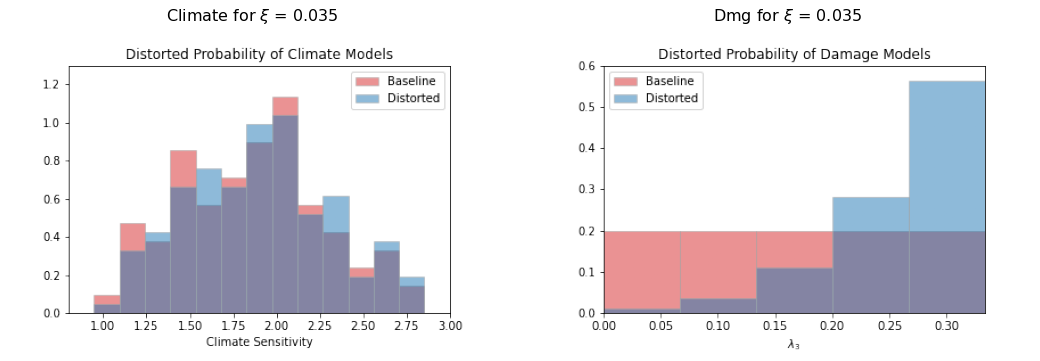

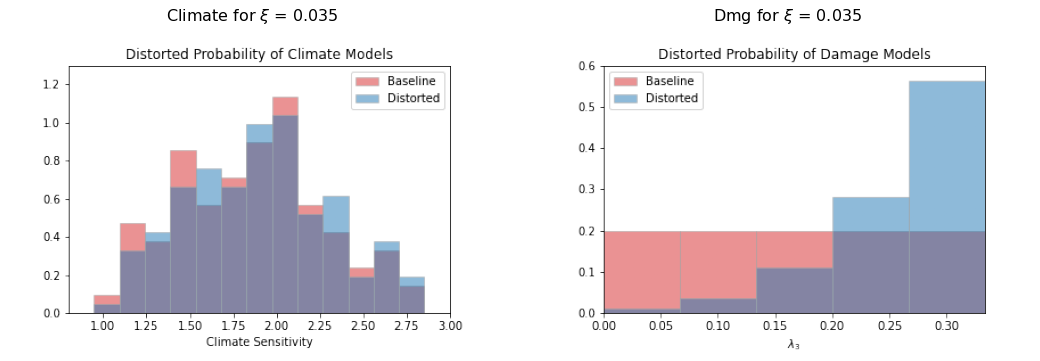

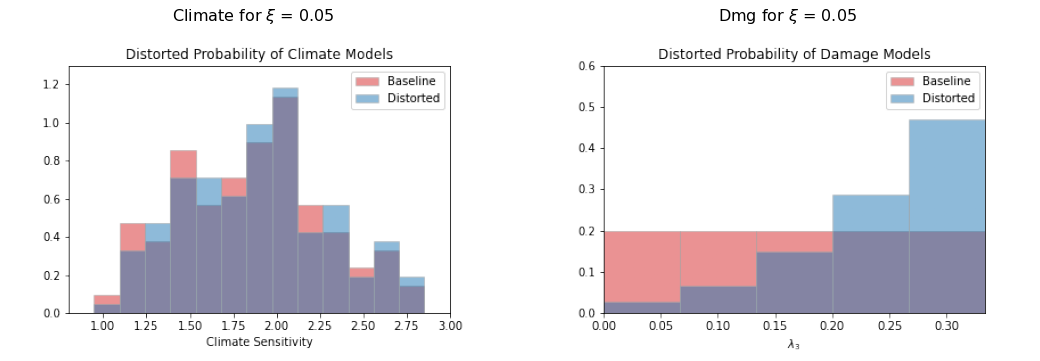

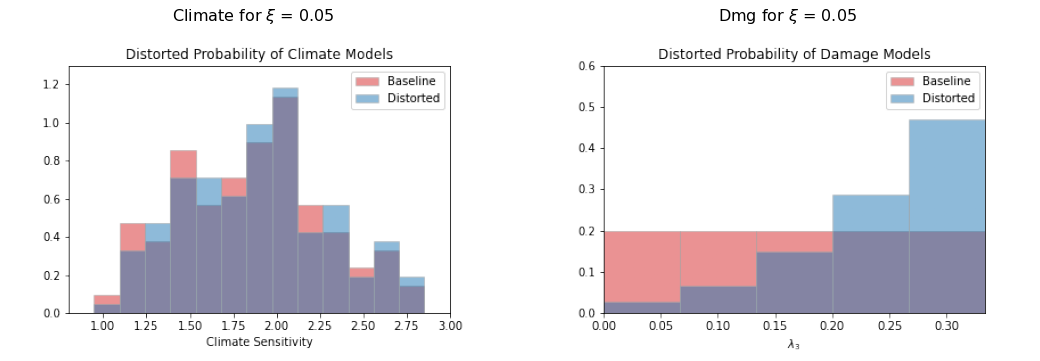

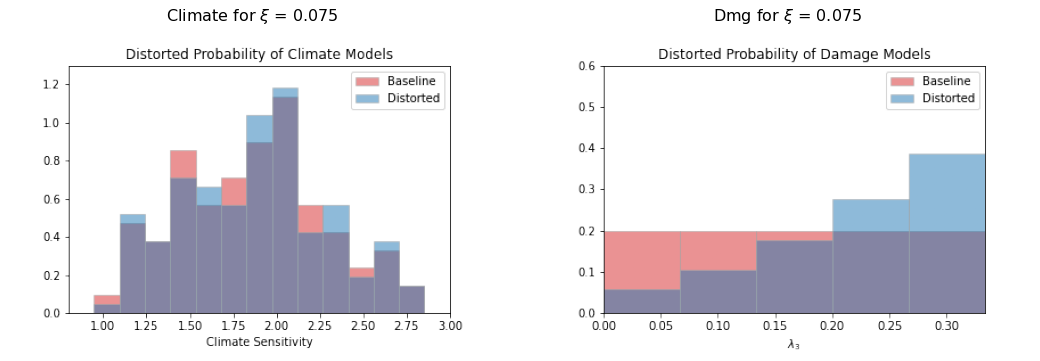

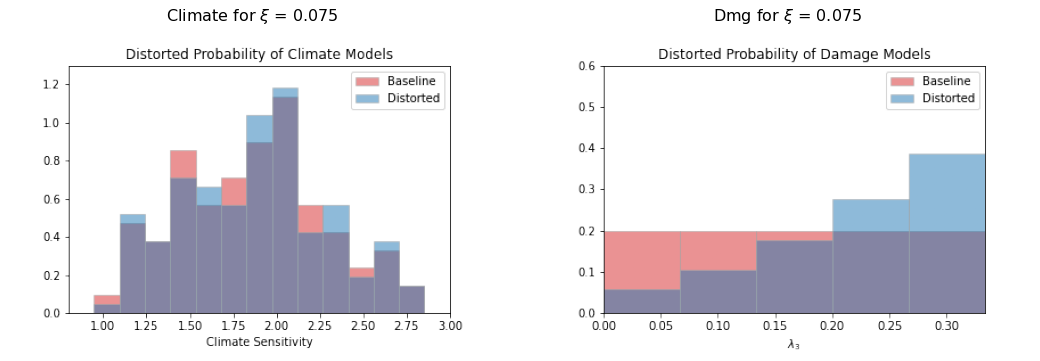

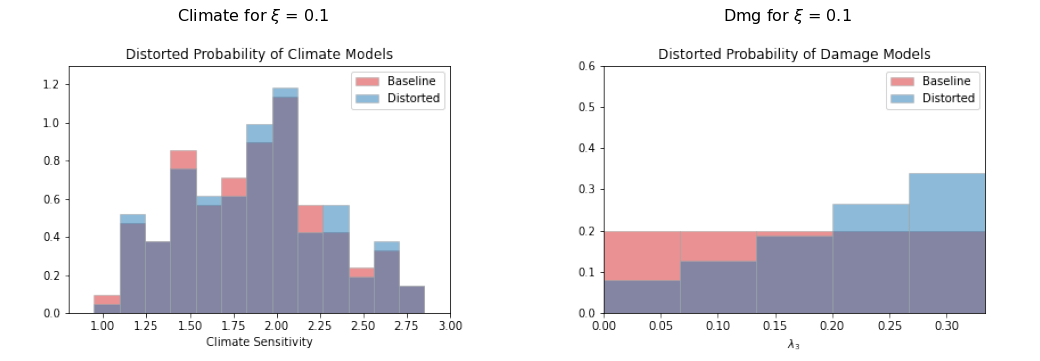

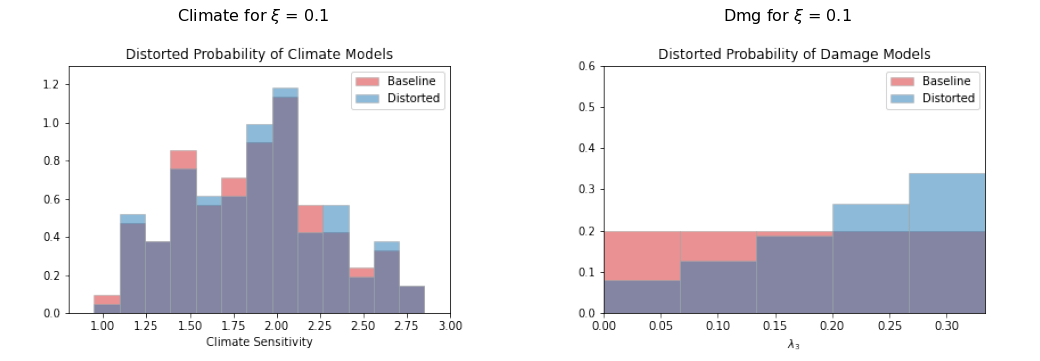

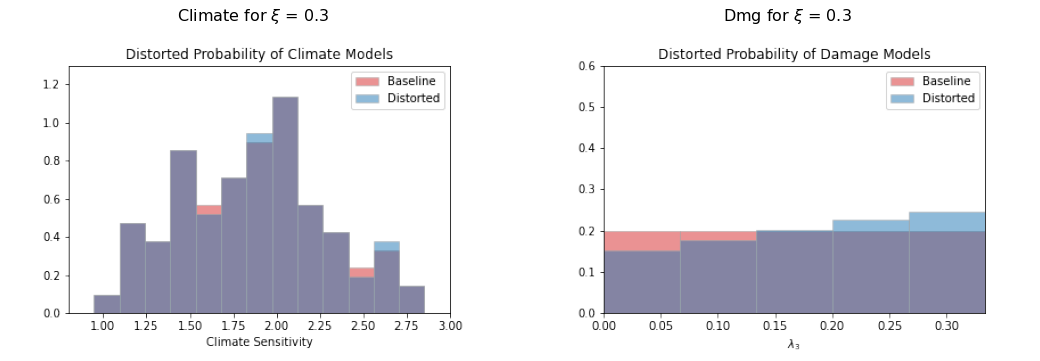

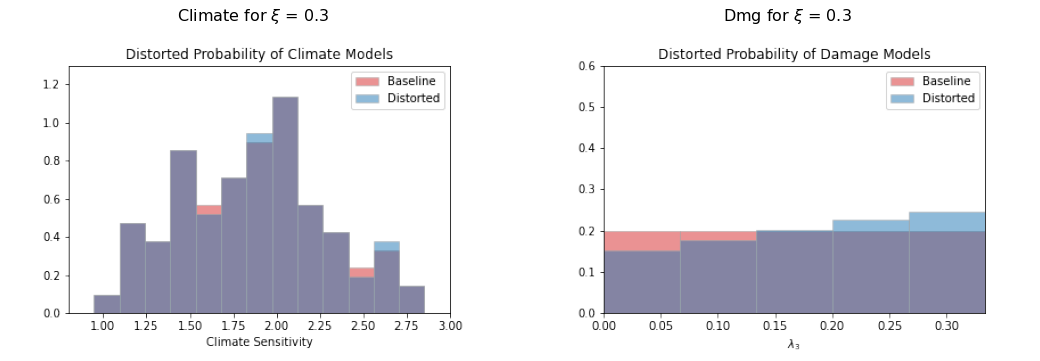

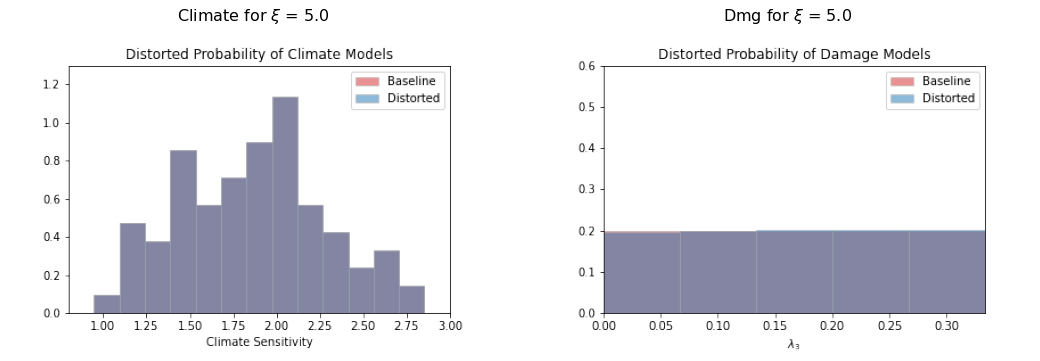

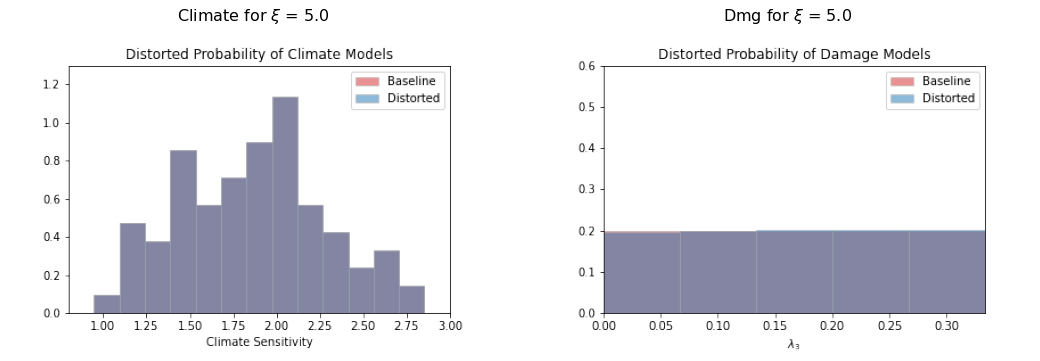

In [5]:
# Image types to display
ImageTypes = ["Climate_Dist.png", "Dmg_Dist.png"]

# Labels for xi values
xi_values = ["0.035","0.050","0.075","0.100", "0.300", "5.000"]
xi_labels = [r'$\xi$ = 0.035',r'$\xi$ = 0.05',r'$\xi$ = 0.075',r'$\xi$ = 0.1', r'$\xi$ = 0.3', r'$\xi$ = 5.0']

# Loop through each xi value
for idx, xi in enumerate(xi_values):
    plt.figure(figsize=(15, 5))  # Make space for multiple plots
    
    # Load and display each type of image
    for i, img_type in enumerate(ImageTypes):
        img_path = f"{FolderName}/PreDamagePreTech/SimulationOutputs_ξ_{xi}/{img_type}"
        img = mpimg.imread(img_path)
        plt.subplot(1, len(ImageTypes), i + 1)  # 1 row, N columns
        plt.imshow(img)
        plt.title(img_type.split("_")[0] + f' for {xi_labels[idx]}', fontsize=16)
        plt.axis("off")  # Hide axes

    plt.tight_layout()
    plt.show()